# RL Crypto Assignment: BTCB-USD Rational Investor Modeling
**Asset:** BTCB-USD (Bitcoin BEP2)  
**Methods:** TD Q-Learning + DQN  
**Scenarios:** Steady-state, Rapid Decline, Rapid Rise  
**Data:** Hourly OHLCV, March 2024 – Feb 2026

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import deque
import random
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
print('Setup complete. PyTorch:', torch.__version__)

Setup complete. PyTorch: 2.9.1


## 2. Data Loading & Preprocessing

In [2]:
DATA_PATH = '/Users/ishan/Downloads/BTCB-USD_DataHr.csv'

# The CSV has 3 header rows; row 0 = column labels, rows 1-2 = metadata
raw = pd.read_csv(DATA_PATH, skiprows=[1, 2], index_col=0, parse_dates=True)
raw.index.name = 'Datetime'
raw.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# Drop rows with NaN prices
df = raw.dropna(subset=['Close']).copy()
df = df.sort_index()

print(f'Shape: {df.shape}')
print(f'Date range: {df.index[0]} -> {df.index[-1]}')
print(f'Missing prices: {df["Close"].isna().sum()}')
print(f'Zero-volume hours: {(df["Volume"] == 0).sum()} ({100*(df["Volume"]==0).mean():.1f}%)')
df.head(3)

Shape: (17248, 5)
Date range: 2024-03-06 00:00:00+00:00 -> 2026-02-23 23:00:00+00:00
Missing prices: 0
Zero-volume hours: 8637 (50.1%)


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-03-06 00:00:00+00:00,63829.664062,63987.660156,63823.457031,63956.105469,0
2024-03-06 01:00:00+00:00,63371.328125,63722.933594,63371.328125,63722.933594,0
2024-03-06 02:00:00+00:00,63196.941406,63350.757812,63196.941406,63291.906250,0


## 3. Feature Engineering

In [3]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def compute_features(df):
    f = pd.DataFrame(index=df.index)
    
    # Price returns at different horizons
    f['ret_1h']   = df['Close'].pct_change(1)
    f['ret_4h']   = df['Close'].pct_change(4)
    f['ret_24h']  = df['Close'].pct_change(24)
    f['ret_168h'] = df['Close'].pct_change(168)  # 1-week
    
    # Volatility (rolling std of 1h log returns, 24h window)
    log_ret = np.log(df['Close'] / df['Close'].shift(1))
    f['vol_24h'] = log_ret.rolling(24).std()
    
    # RSI
    f['rsi_14'] = compute_rsi(df['Close'], 14) / 100.0  # normalized 0-1
    
    # Price relative to moving averages (Bollinger band position)
    ma20 = df['Close'].rolling(20).mean()
    ma50 = df['Close'].rolling(50).mean()
    std20 = df['Close'].rolling(20).std()
    f['price_vs_ma20'] = (df['Close'] - ma20) / (std20 + 1e-9)  # z-score
    f['price_vs_ma50'] = (df['Close'] - ma50) / (ma50 + 1e-9)   # % deviation
    
    # Hour-of-day (cyclical encoding)
    hour = df.index.hour
    f['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    f['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    
    # Log volume (when non-zero, else 0)
    f['log_vol'] = np.where(df['Volume'] > 0, np.log(df['Volume'] + 1), 0)
    f['log_vol'] = (f['log_vol'] - f['log_vol'].mean()) / (f['log_vol'].std() + 1e-9)
    
    # High-Low range (intra-hour volatility proxy)
    f['hl_range'] = (df['High'] - df['Low']) / df['Close']
    
    return f

features = compute_features(df)

# Clip extreme returns to prevent outliers destabilizing training
for col in ['ret_1h', 'ret_4h', 'ret_24h', 'ret_168h']:
    features[col] = features[col].clip(-0.5, 0.5)

# Drop warmup rows (first 168h for feature validity)
features = features.dropna()
df_aligned = df.loc[features.index]

FEATURE_COLS = features.columns.tolist()
print(f'Features: {FEATURE_COLS}')
print(f'Feature matrix shape: {features.shape}')
features.describe().round(4)

Features: ['ret_1h', 'ret_4h', 'ret_24h', 'ret_168h', 'vol_24h', 'rsi_14', 'price_vs_ma20', 'price_vs_ma50', 'hour_sin', 'hour_cos', 'log_vol', 'hl_range']
Feature matrix shape: (17080, 12)


,ret_1h,ret_4h,ret_24h,ret_168h,vol_24h,rsi_14,price_vs_ma20,price_vs_ma50,hour_sin,hour_cos,log_vol,hl_range
count,17080.0000,17080.0000,17080.0000,17080.0000,17080.0000,17080.0000,17080.0000,17080.0000,17080.0000,17080.0000,17080.0000,17080.0000
mean,0.0000,0.0000,0.0002,0.0017,0.0041,0.5074,0.0301,-0.0000,-0.0005,0.0004,-0.0019,0.0037
std,0.0048,0.0101,0.0245,0.0616,0.0024,0.1937,1.3364,0.0196,0.7071,0.7071,0.9987,0.0043
min,-0.0585,-0.0821,-0.1760,-0.2795,0.0003,0.0178,-4.0330,-0.1425,-1.0000,-1.0000,-0.9867,0.0000
25%,-0.0016,-0.0039,-0.0125,-0.0361,0.0025,0.3625,-0.9995,-0.0100,-0.7071,-0.7071,-0.9867,0.0014
50%,0.0001,0.0001,0.0004,0.0010,0.0037,0.5068,0.0973,0.0004,0.0000,0.0000,-0.9867,0.0024
75%,0.0017,0.0043,0.0128,0.0373,0.0051,0.6531,1.0529,0.0108,0.7071,0.7071,1.0043,0.0045
max,0.0749,0.0993,0.1233,0.3138,0.0206,0.9959,4.0429,0.1001,1.0000,1.0000,1.7863,0.1645


## 4. Market Regime Detection
Label each hour as one of three regimes based on 24h trailing return and volatility.

Regime distribution:
steady     16150
rise         473
decline      457
Name: count, dtype: int64

As % of data:
steady     94.6
rise        2.8
decline     2.7
Name: count, dtype: float64


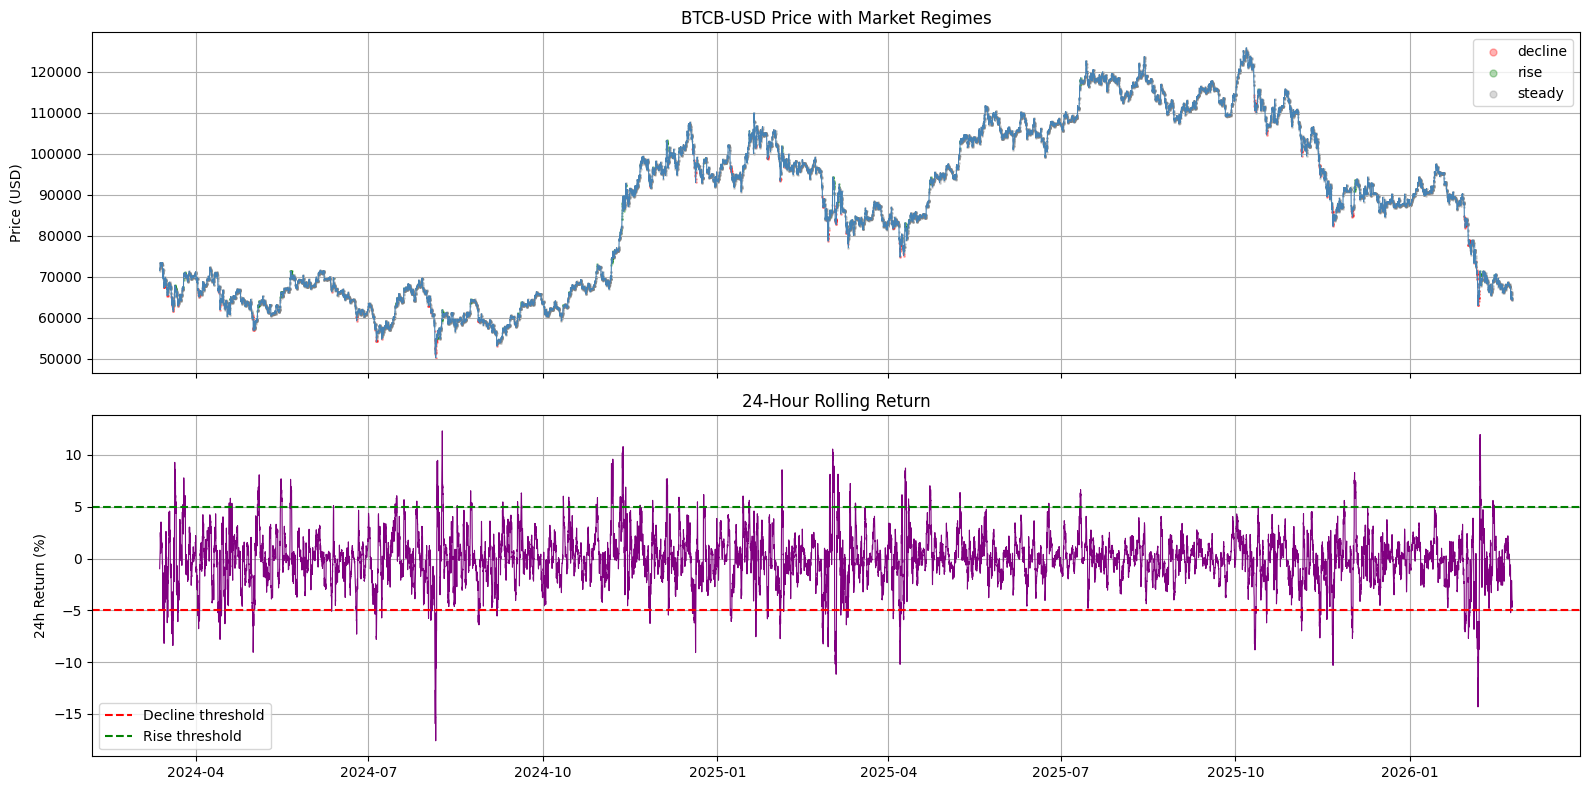

In [4]:
# Regime thresholds
DECLINE_THRESH = -0.05   # 24h return < -5% -> Rapid Decline
RISE_THRESH    =  0.05   # 24h return >  5% -> Rapid Rise
# Otherwise: Steady-State

ret24 = features['ret_24h']
regime = pd.Series('steady', index=features.index)
regime[ret24 < DECLINE_THRESH] = 'decline'
regime[ret24 > RISE_THRESH]    = 'rise'

regime_counts = regime.value_counts()
print('Regime distribution:')
print(regime_counts)
print(f'\nAs % of data:')
print((regime_counts / len(regime) * 100).round(1))

# Visualize regimes on price chart
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df_aligned.index, df_aligned['Close'], lw=0.8, color='steelblue')
for reg, color in [('decline', 'red'), ('rise', 'green'), ('steady', 'gray')]:
    mask = regime == reg
    axes[0].scatter(df_aligned.index[mask], df_aligned['Close'][mask],
                    s=1, c=color, alpha=0.3, label=reg)
axes[0].set_title('BTCB-USD Price with Market Regimes')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(markerscale=5)

axes[1].plot(features.index, features['ret_24h'] * 100, lw=0.8, color='purple')
axes[1].axhline(DECLINE_THRESH * 100, color='red', linestyle='--', label='Decline threshold')
axes[1].axhline(RISE_THRESH * 100, color='green', linestyle='--', label='Rise threshold')
axes[1].set_ylabel('24h Return (%)')
axes[1].set_title('24-Hour Rolling Return')
axes[1].legend()

plt.tight_layout()
plt.savefig('/Users/ishan/Downloads/regimes.png', dpi=150)
plt.show()

## 5. Trading Environment
A simple gym-style environment. At each step the agent decides: **Hold (0), Buy (1), or Sell (2)**.

In [5]:
TRANSACTION_COST = 0.001
INITIAL_CASH     = 10_000.0

class CryptoEnv:
    """
    Single-asset crypto trading environment.
    Actions: 0=Hold, 1=Buy (all cash -> crypto), 2=Sell (all crypto -> cash)
    Reward: log return of portfolio value (raw P&L signal)
    """
    N_ACTIONS = 3

    def __init__(self, features_df, prices, regime_series=None, target_regime=None):
        self.features   = features_df.values.astype(np.float32)
        self.prices     = prices.values.astype(np.float32)
        self.n_features = self.features.shape[1]
        self.state_dim  = self.n_features + 1

        if target_regime and regime_series is not None:
            regime_arr = regime_series.values
            self.valid_starts = np.where(regime_arr == target_regime)[0]
            self.valid_starts = self.valid_starts[self.valid_starts < len(self.prices) - 24]
        else:
            self.valid_starts = np.arange(len(self.prices) - 24)

        self.reset()

    def reset(self, start_idx=None):
        if start_idx is None:
            self.t = int(np.random.choice(self.valid_starts))
        else:
            self.t = start_idx
        self.cash       = INITIAL_CASH
        self.crypto     = 0.0
        self.prev_value = INITIAL_CASH
        return self._get_state()

    def _portfolio_value(self):
        return self.cash + self.crypto * self.prices[self.t]

    def _get_state(self):
        pv = self._portfolio_value()
        crypto_frac = (self.crypto * self.prices[self.t]) / (pv + 1e-9)
        return np.append(self.features[self.t], crypto_frac).astype(np.float32)

    def step(self, action):
        price = self.prices[self.t]
        if action == 1 and self.cash > 1.0:
            spend        = self.cash * (1 - TRANSACTION_COST)
            self.crypto += spend / price
            self.cash    = max(self.cash - spend - self.cash * TRANSACTION_COST, 0.0)
        elif action == 2 and self.crypto > 1e-6:
            self.cash   += self.crypto * price * (1 - TRANSACTION_COST)
            self.crypto  = 0.0

        self.t += 1
        done = (self.t >= len(self.prices) - 1)
        curr_value = self._portfolio_value()
        reward = np.clip(np.log(curr_value / (self.prev_value + 1e-9)), -1.0, 1.0)
        self.prev_value = curr_value
        return self._get_state(), reward, done


print(f"State dimension: {len(FEATURE_COLS) + 1}")
print(f"Action space: {{0: Hold, 1: Buy, 2: Sell}}")
env_test = CryptoEnv(features, df_aligned["Close"], regime)
s = env_test.reset(); s2, r, done = env_test.step(1)
print(f"State shape: {s.shape}, Reward after Buy: {r:.4f}")


State dimension: 13
Action space: {0: Hold, 1: Buy, 2: Sell}
State shape: (13,), Reward after Buy: 0.0025


## 6. TD Q-Learning Agent (Tabular)
We discretize the continuous state into bins to build a Q-table.

In [6]:
class TDAgent:
    """
    Tabular Q-Learning with discretized state space.
    Uses a subset of features: ret_1h, ret_24h, rsi_14, price_vs_ma20, portfolio_fraction.
    """
    N_ACTIONS = 3

    FEAT_IDX = {
        'ret_1h':          FEATURE_COLS.index('ret_1h'),
        'ret_24h':         FEATURE_COLS.index('ret_24h'),
        'rsi_14':          FEATURE_COLS.index('rsi_14'),
        'price_vs_ma20':   FEATURE_COLS.index('price_vs_ma20'),
        'portfolio_frac':  len(FEATURE_COLS)
    }

    BINS = {
        'ret_1h':         [-0.02, -0.005, 0.005, 0.02],
        'ret_24h':        [-0.05, -0.01,  0.01,  0.05],
        'rsi_14':         [0.3,   0.5,    0.7],
        'price_vs_ma20':  [-1.0,  0.0,    1.0],
        'portfolio_frac': [0.1,   0.5,    0.9],
    }

    def __init__(self, alpha=0.1, gamma=0.99, epsilon=1.0,
                 epsilon_min=0.05, epsilon_decay=0.99999):
        # epsilon_decay=0.99999: reaches 0.05 after ~300k steps
        # 3000 eps x 168 steps = 504k total -> decays at ~60% of training
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.n_bins = {k: len(v) + 1 for k, v in self.BINS.items()}
        n_states = 1
        for n in self.n_bins.values():
            n_states *= n
        self.n_states = n_states
        self.Q = np.zeros((n_states, self.N_ACTIONS))
        print(f'Q-table size: {n_states} states x {self.N_ACTIONS} actions = {n_states * self.N_ACTIONS} entries')

    def _discretize(self, state):
        buckets = []
        for feat, idx in self.FEAT_IDX.items():
            val = state[idx]
            bucket = np.digitize(val, self.BINS[feat])
            buckets.append(bucket)
        state_idx = 0
        for feat, b in zip(self.FEAT_IDX.keys(), buckets):
            state_idx = state_idx * self.n_bins[feat] + b
        return state_idx

    def act(self, state, greedy=False):
        if not greedy and np.random.rand() < self.epsilon:
            return np.random.randint(self.N_ACTIONS)
        s = self._discretize(state)
        return int(np.argmax(self.Q[s]))

    def update(self, state, action, reward, next_state, done):
        s  = self._discretize(state)
        s_ = self._discretize(next_state)
        target = reward + (0 if done else self.gamma * np.max(self.Q[s_]))
        self.Q[s, action] += self.alpha * (target - self.Q[s, action])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


td_agent = TDAgent()


Q-table size: 1600 states x 3 actions = 4800 entries


## 7. DQN Agent (PyTorch)

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

class QNetwork(nn.Module):
    """
    MLP Q-function with optimistic initialization on the output layer.
    All Q-values start at +0.1 so every action looks equally promising.
    The agent must actively try actions and downdate bad ones
    rather than defaulting to a trivial constant policy early in training.
    """
    def __init__(self, state_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
        # Optimistic init: output bias = +0.1 for all actions
        with torch.no_grad():
            self.net[-1].bias.fill_(0.1)

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buf = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buf.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s_, d = zip(*batch)
        return (torch.FloatTensor(np.array(s)).to(DEVICE),
                torch.LongTensor(a).to(DEVICE),
                torch.FloatTensor(r).to(DEVICE),
                torch.FloatTensor(np.array(s_)).to(DEVICE),
                torch.FloatTensor(d).to(DEVICE))

    def __len__(self):
        return len(self.buf)


class DQNAgent:
    def __init__(self, state_dim, n_actions=3,
                 lr=3e-4, gamma=0.99, epsilon=1.0,
                 epsilon_min=0.05, epsilon_decay=0.99999,
                 batch_size=128, target_update_freq=1000,
                 weight_decay=1e-4):
        self.n_actions         = n_actions
        self.gamma             = gamma
        self.epsilon           = epsilon
        self.epsilon_min       = epsilon_min
        self.epsilon_decay     = epsilon_decay
        self.batch_size        = batch_size
        self.target_update_freq = target_update_freq
        self.steps = 0

        self.q_net      = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr, weight_decay=weight_decay)
        self.buffer    = ReplayBuffer(capacity=100_000)

    def act(self, state, greedy=False):
        if not greedy and np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        self.q_net.eval()
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            q = self.q_net(s)
        return int(q.argmax().item())

    def update(self, state, action, reward, next_state, done):
        self.buffer.push(state, action, reward, next_state, done)
        if len(self.buffer) < self.batch_size * 4:
            return None

        s, a, r, s_, d = self.buffer.sample(self.batch_size)

        self.q_net.train()
        q_vals = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze()

        with torch.no_grad():
            self.q_net.eval()
            next_actions = self.q_net(s_).argmax(1)
            self.q_net.train()
            next_q = self.target_net(s_).gather(1, next_actions.unsqueeze(1)).squeeze()
            targets = r + self.gamma * next_q * (1 - d)

        loss = F.smooth_l1_loss(q_vals, targets)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


STATE_DIM = len(FEATURE_COLS) + 1
dqn_agent = DQNAgent(state_dim=STATE_DIM)
print(f"DQN parameters: {sum(p.numel() for p in dqn_agent.q_net.parameters()):,}")
# Verify optimistic init
with torch.no_grad():
    dummy = torch.zeros(1, STATE_DIM)
    q_init = dqn_agent.q_net(dummy).numpy()[0]
print(f"Initial Q-values (all actions should be ≈ 0.1): {q_init.round(4)}")


Device: cpu


DQN parameters: 18,691
Initial Q-values (all actions should be ≈ 0.1): [0.059  0.0917 0.0828]


## 8. Training Loop
Train both agents on the full dataset using random episode start points.

In [8]:
def run_episode(env, agent, episode_len=168, train=True):
    """Run one episode of length `episode_len` hours."""
    state = env.reset()
    total_reward = 0.0
    for _ in range(episode_len):
        action = agent.act(state, greedy=not train)
        next_state, reward, env_done = env.step(action)
        total_reward += reward
        if train:
            agent.update(state, action, reward, next_state, env_done)
            agent.decay_epsilon()
        state = next_state
        if env_done:
            break
    return total_reward


def train_agent(agent, env, n_episodes=1000, episode_len=168, log_every=100):
    """Standard (unbalanced) training — used for TD agent."""
    rewards = []
    for ep in range(n_episodes):
        r = run_episode(env, agent, episode_len=episode_len, train=True)
        rewards.append(r)
        if (ep + 1) % log_every == 0:
            eps = getattr(agent, "epsilon", "-")
            print(f"  Episode {ep+1:4d} | Avg reward: {np.mean(rewards[-100:]):.4f} | epsilon: {eps:.3f}")
    return rewards


def train_dqn_balanced(agent, features_tr, prices_tr, regime_tr,
                       n_episodes=3000, episode_len=168, log_every=300,
                       decline_frac=0.20, rise_frac=0.20,
                       checkpoint_start=1000, checkpoint_every=50):
    """
    Regime-balanced DQN training with best-checkpoint saving.

    Regime mix during training:
      decline_frac  -> episodes start in a Rapid Decline window
      rise_frac     -> episodes start in a Rapid Rise window
      remainder     -> random start from full training set

    Checkpoint: after `checkpoint_start` episodes, saves weights whenever
    the 100-episode rolling average reward improves. Restores best at end.
    """
    env_all     = CryptoEnv(features_tr, prices_tr, regime_tr)
    env_decline = CryptoEnv(features_tr, prices_tr, regime_tr, target_regime="decline")
    env_rise    = CryptoEnv(features_tr, prices_tr, regime_tr, target_regime="rise")

    n_decline = len(env_decline.valid_starts)
    n_rise    = len(env_rise.valid_starts)
    print(f"  Valid decline starts: {n_decline}  |  Valid rise starts: {n_rise}")

    rewards = []
    best_reward  = -np.inf
    best_weights = None

    for ep in range(n_episodes):
        roll = np.random.rand()
        if roll < decline_frac and n_decline > 0:
            env = env_decline
        elif roll < decline_frac + rise_frac and n_rise > 0:
            env = env_rise
        else:
            env = env_all

        r = run_episode(env, agent, episode_len=episode_len, train=True)
        rewards.append(r)

        # Save best checkpoint (only after exploration phase)
        if ep >= checkpoint_start and (ep % checkpoint_every == 0):
            recent_avg = np.mean(rewards[-100:])
            if recent_avg > best_reward:
                best_reward  = recent_avg
                best_weights = {k: v.clone().cpu() for k, v in agent.q_net.state_dict().items()}

        if (ep + 1) % log_every == 0:
            recent = np.mean(rewards[-100:])
            print(f"  Episode {ep+1:4d} | Avg reward: {recent:.4f} | epsilon: {agent.epsilon:.3f} | Best ckpt: {best_reward:.4f}")

    # Restore best checkpoint
    if best_weights is not None:
        agent.q_net.load_state_dict({k: v.to(DEVICE) for k, v in best_weights.items()})
        agent.target_net.load_state_dict(agent.q_net.state_dict())
        print(f"\nRestored best checkpoint (rolling avg reward: {best_reward:.4f})")

    return rewards


# --- Train/test split (unchanged: 80/20) ---
split_idx       = int(len(features) * 0.80)
features_train  = features.iloc[:split_idx]
features_test   = features.iloc[split_idx:]
prices_train    = df_aligned["Close"].iloc[:split_idx]
prices_test     = df_aligned["Close"].iloc[split_idx:]
regime_train    = regime.iloc[:split_idx]
regime_test     = regime.iloc[split_idx:]

print(f"Train: {features_train.index[0]} -> {features_train.index[-1]}  ({len(features_train)} hours)")
print(f"Test : {features_test.index[0]}  -> {features_test.index[-1]}  ({len(features_test)} hours)")


Train: 2024-03-13 00:00:00+00:00 -> 2025-10-03 08:00:00+00:00  (13664 hours)
Test : 2025-10-03 09:00:00+00:00  -> 2026-02-23 23:00:00+00:00  (3416 hours)


In [9]:
# --- Train TD Agent ---
print("=== Training TD Q-Learning Agent ===")
td_agent = TDAgent(alpha=0.1, epsilon_decay=0.99999)
env_td   = CryptoEnv(features_train, prices_train, regime_train)
td_rewards = train_agent(td_agent, env_td, n_episodes=3000, episode_len=168, log_every=300)
print(f"Final epsilon: {td_agent.epsilon:.4f}")


=== Training TD Q-Learning Agent ===
Q-table size: 1600 states x 3 actions = 4800 entries


  Episode  300 | Avg reward: -0.0370 | epsilon: 0.606


  Episode  600 | Avg reward: -0.0200 | epsilon: 0.367


  Episode  900 | Avg reward: -0.0148 | epsilon: 0.222


  Episode 1200 | Avg reward: -0.0142 | epsilon: 0.134


...

  Episode 1800 | Avg reward: 0.0027 | epsilon: 0.050


  Episode 2100 | Avg reward: 0.0004 | epsilon: 0.050


  Episode 2400 | Avg reward: 0.0040 | epsilon: 0.050


  Episode 2700 | Avg reward: 0.0003 | epsilon: 0.050


  Episode 3000 | Avg reward: 0.0040 | epsilon: 0.050
Final epsilon: 0.0500


In [10]:
# --- Train DQN Agent ---
print("=== Training DQN Agent ===")
print("Fixes: optimistic Q-init (+0.1 bias), regime balance 15/15/70,")
print("       L2 reg, hidden=128, dropout=0.05, checkpoint saving")

dqn_agent = DQNAgent(state_dim=STATE_DIM, lr=3e-4, batch_size=128,
                     target_update_freq=1000, epsilon_decay=0.99999,
                     weight_decay=1e-4)

env_all     = CryptoEnv(features_train, prices_train, regime_train)
env_decline = CryptoEnv(features_train, prices_train, regime_train, target_regime="decline")
env_rise    = CryptoEnv(features_train, prices_train, regime_train, target_regime="rise")
print(f"  Decline starts: {len(env_decline.valid_starts)} | Rise starts: {len(env_rise.valid_starts)}")

DECLINE_FRAC, RISE_FRAC = 0.15, 0.15
N_EPISODES, EP_LEN = 2000, 168
CKPT_START, CKPT_EVERY = 800, 50

rewards_dqn = []
best_reward, best_weights = -np.inf, None

for ep in range(N_EPISODES):
    roll = np.random.rand()
    if roll < DECLINE_FRAC and len(env_decline.valid_starts) > 0:
        env = env_decline
    elif roll < DECLINE_FRAC + RISE_FRAC and len(env_rise.valid_starts) > 0:
        env = env_rise
    else:
        env = env_all

    r = run_episode(env, dqn_agent, episode_len=EP_LEN, train=True)
    rewards_dqn.append(r)

    if ep >= CKPT_START and ep % CKPT_EVERY == 0:
        avg = np.mean(rewards_dqn[-100:])
        if avg > best_reward:
            best_reward  = avg
            best_weights = {k: v.clone().cpu() for k, v in dqn_agent.q_net.state_dict().items()}

    if (ep + 1) % 200 == 0:
        avg = np.mean(rewards_dqn[-100:])
        print(f"  Ep {ep+1:4d} | Avg reward: {avg:.4f} | eps: {dqn_agent.epsilon:.3f} | Best ckpt: {best_reward:.4f}")

if best_weights is not None:
    dqn_agent.q_net.load_state_dict({k: v.to(DEVICE) for k, v in best_weights.items()})
    dqn_agent.target_net.load_state_dict(dqn_agent.q_net.state_dict())
    print(f"Restored best checkpoint (rolling avg: {best_reward:.4f})")

dqn_rewards = rewards_dqn
print(f"Final epsilon: {dqn_agent.epsilon:.4f} | Buffer: {len(dqn_agent.buffer):,}")

# Show learned Q-values on a sample state to verify non-trivial policy
sample_state = env_all.reset()
dqn_agent.q_net.eval()
with torch.no_grad():
    q_vals = dqn_agent.q_net(torch.FloatTensor(sample_state).unsqueeze(0)).numpy()[0]
action_names = ["Hold", "Buy", "Sell"]
print(f"Sample Q-values: Hold={q_vals[0]:.4f} Buy={q_vals[1]:.4f} Sell={q_vals[2]:.4f}")
print(f"Preferred action: {action_names[np.argmax(q_vals)]}")


=== Training DQN Agent ===
Fixes: optimistic Q-init (+0.1 bias), regime balance 15/15/70,
       L2 reg, hidden=128, dropout=0.05, checkpoint saving
  Decline starts: 290 | Rise starts: 426


  Ep  200 | Avg reward: -0.0437 | eps: 0.717 | Best ckpt: -inf


  Ep  400 | Avg reward: -0.0315 | eps: 0.513 | Best ckpt: -inf


  Ep  600 | Avg reward: -0.0239 | eps: 0.367 | Best ckpt: -inf


  Ep  800 | Avg reward: -0.0105 | eps: 0.263 | Best ckpt: -inf


...

  Ep 1200 | Avg reward: -0.0022 | eps: 0.135 | Best ckpt: 0.0007


  Ep 1400 | Avg reward: -0.0029 | eps: 0.096 | Best ckpt: 0.0007


  Ep 1600 | Avg reward: -0.0071 | eps: 0.069 | Best ckpt: 0.0007


  Ep 1800 | Avg reward: 0.0077 | eps: 0.050 | Best ckpt: 0.0104


  Ep 2000 | Avg reward: 0.0010 | eps: 0.050 | Best ckpt: 0.0104
Restored best checkpoint (rolling avg: 0.0104)
Final epsilon: 0.0500 | Buffer: 100,000
Sample Q-values: Hold=0.0043 Buy=0.0041 Sell=0.0033
Preferred action: Hold


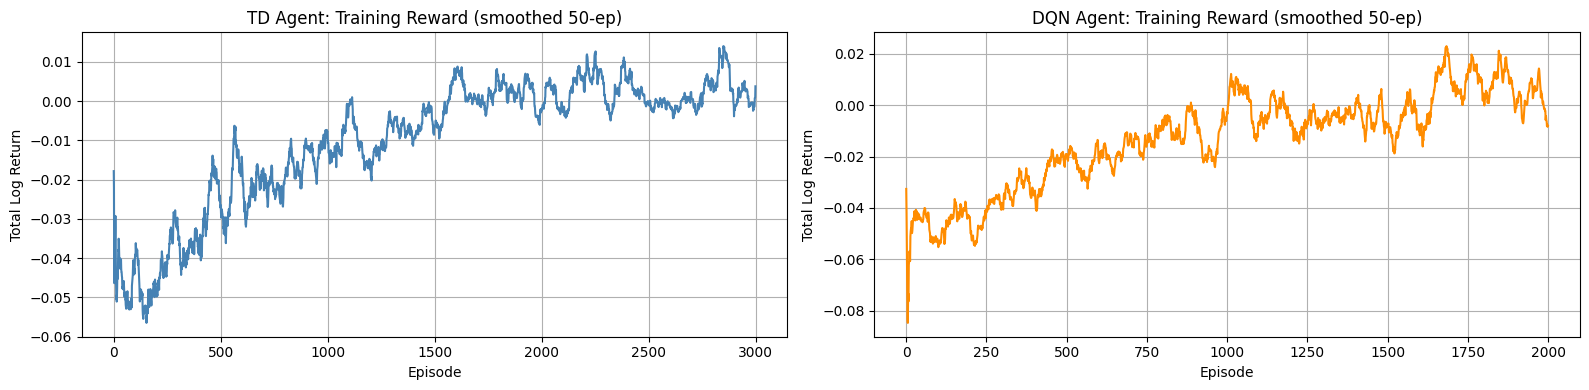

In [11]:
# Plot training curves
def smooth(x, w=50):
    return pd.Series(x).rolling(w, min_periods=1).mean().values

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(smooth(td_rewards), label='TD Q-Learning', color='steelblue')
axes[0].set_title('TD Agent: Training Reward (smoothed 50-ep)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total Log Return')

axes[1].plot(smooth(dqn_rewards), label='DQN', color='darkorange')
axes[1].set_title('DQN Agent: Training Reward (smoothed 50-ep)')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Total Log Return')

plt.tight_layout()
plt.savefig('/Users/ishan/Downloads/training_curves.png', dpi=150)
plt.show()

## 9. Backtesting
Run agents on the held-out test set and compare vs Buy-and-Hold baseline.

In [12]:
def backtest_full(agent, features_df, prices, label='Agent'):
    """
    Run agent sequentially on the entire test set (no re-randomization).
    Returns portfolio value series and action series.
    """
    feat = features_df.values.astype(np.float32)
    price = prices.values.astype(np.float32)
    T = len(price)

    cash, crypto = INITIAL_CASH, 0.0
    port_values  = [INITIAL_CASH]
    actions_list = []

    for t in range(T - 1):
        p = price[t]
        port_val = cash + crypto * p
        crypto_frac = (crypto * p) / (port_val + 1e-9)
        state = np.append(feat[t], crypto_frac).astype(np.float32)

        action = agent.act(state, greedy=True)
        actions_list.append(action)

        if action == 1 and cash > 1.0:
            spend = cash * (1 - TRANSACTION_COST)
            crypto += spend / p
            cash = cash - spend - (cash * TRANSACTION_COST)
            cash = max(cash, 0.0)
        elif action == 2 and crypto > 1e-6:
            cash += crypto * p * (1 - TRANSACTION_COST)
            crypto = 0.0

        port_values.append(cash + crypto * price[t + 1])

    actions_arr = np.array(actions_list)
    pv_series = pd.Series(port_values, index=features_df.index[:T])
    return pv_series, actions_arr


def buy_and_hold(prices, init_cash=INITIAL_CASH):
    units = init_cash * (1 - TRANSACTION_COST) / prices.iloc[0]
    return pd.Series(units * prices.values, index=prices.index)


def compute_metrics(pv_series, prices, label=''):
    """Compute Sharpe, Max Drawdown, Total Return, Calmar."""
    rets = pv_series.pct_change().dropna()
    total_ret = (pv_series.iloc[-1] / pv_series.iloc[0] - 1) * 100
    ann_ret = (1 + rets.mean()) ** (24 * 365) - 1  # hourly -> annualized
    ann_vol = rets.std() * np.sqrt(24 * 365)
    sharpe  = ann_ret / (ann_vol + 1e-9)
    roll_max = pv_series.cummax()
    drawdown = (pv_series - roll_max) / roll_max
    max_dd = drawdown.min() * 100
    calmar  = ann_ret / (abs(max_dd / 100) + 1e-9)
    return {
        'Strategy': label,
        'Total Return (%)': round(total_ret, 2),
        'Ann. Return (%)':  round(ann_ret * 100, 2),
        'Ann. Volatility (%)': round(ann_vol * 100, 2),
        'Sharpe Ratio':    round(sharpe, 3),
        'Max Drawdown (%)': round(max_dd, 2),
        'Calmar Ratio':    round(calmar, 3),
        'Final Portfolio ($)': round(pv_series.iloc[-1], 2)
    }


# Run backtests
td_pv,  td_actions  = backtest_full(td_agent,  features_test, prices_test, 'TD')
dqn_pv, dqn_actions = backtest_full(dqn_agent, features_test, prices_test, 'DQN')
bnh_pv  = buy_and_hold(prices_test)

metrics_td  = compute_metrics(td_pv,  prices_test, 'TD Q-Learning')
metrics_dqn = compute_metrics(dqn_pv, prices_test, 'DQN')
metrics_bnh = compute_metrics(bnh_pv, prices_test, 'Buy & Hold')

results_df = pd.DataFrame([metrics_bnh, metrics_td, metrics_dqn]).set_index('Strategy')
print('=== BACKTEST RESULTS ===')
display(results_df)

=== BACKTEST RESULTS ===


,Total Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),Calmar Ratio,Final Portfolio ($)
Strategy,,,,,,,
Buy & Hold,-46.21,-77.31,46.33,-1.669,-49.99,-1.546,5373.44
TD Q-Learning,-0.15,0.25,11.30,0.022,-5.08,0.049,9984.70
DQN,0.00,0.00,0.00,0.000,0.00,0.000,10000.00


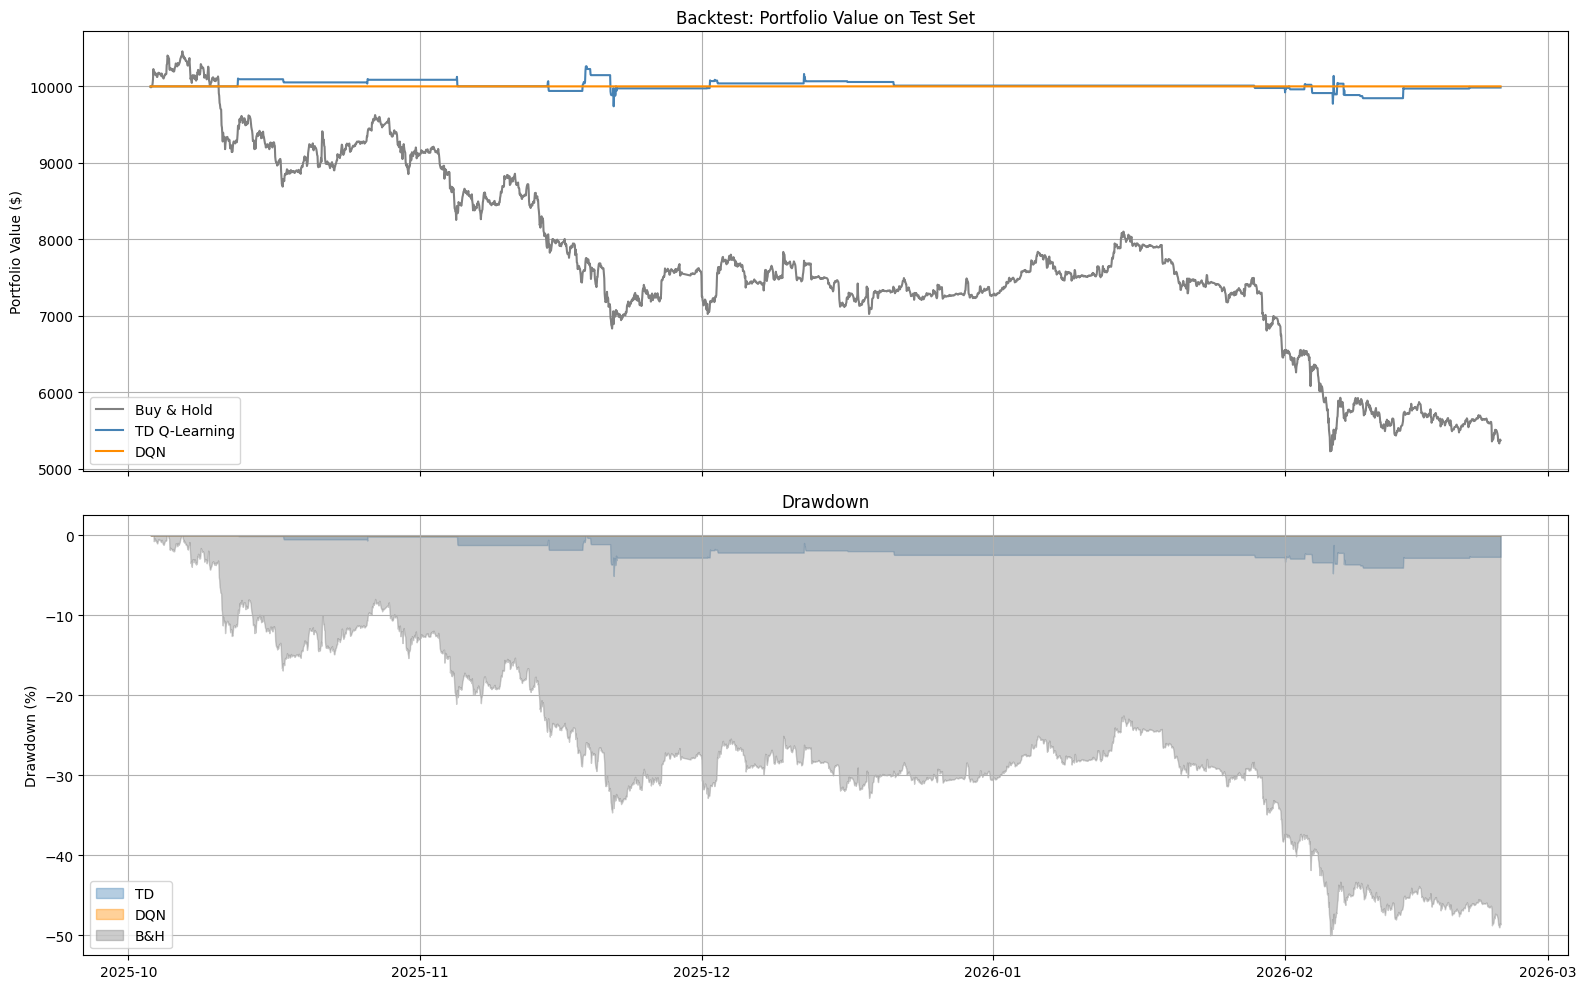

In [13]:
# Portfolio value over time
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(bnh_pv.index, bnh_pv.values,   label='Buy & Hold', lw=1.5, color='gray')
axes[0].plot(td_pv.index,  td_pv.values,    label='TD Q-Learning', lw=1.5, color='steelblue')
axes[0].plot(dqn_pv.index, dqn_pv.values,   label='DQN', lw=1.5, color='darkorange')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title('Backtest: Portfolio Value on Test Set')
axes[0].legend()

# Drawdowns
for pv, label, color in [(td_pv, 'TD', 'steelblue'), (dqn_pv, 'DQN', 'darkorange'), (bnh_pv, 'B&H', 'gray')]:
    dd = (pv - pv.cummax()) / pv.cummax() * 100
    axes[1].fill_between(dd.index, dd.values, 0, alpha=0.4, label=label, color=color)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown')
axes[1].legend()

plt.tight_layout()
plt.savefig('/Users/ishan/Downloads/backtest_results.png', dpi=150)
plt.show()

## 10. Regime-Specific Performance Analysis

In [14]:
def regime_metrics(pv_series, regime_series, label=''):
    """Compute Sharpe per regime."""
    rows = []
    for reg in ['steady', 'decline', 'rise']:
        mask = regime_series == reg
        pv_reg = pv_series[mask]
        if len(pv_reg) < 10:
            continue
        rets = pv_reg.pct_change().dropna()
        ann_ret = (1 + rets.mean()) ** (24 * 365) - 1
        ann_vol = rets.std() * np.sqrt(24 * 365)
        sharpe  = ann_ret / (ann_vol + 1e-9)
        total_r = (pv_reg.iloc[-1] / pv_reg.iloc[0] - 1) * 100 if len(pv_reg) > 1 else 0
        rows.append({
            'Strategy': label, 'Regime': reg,
            'Hours': len(pv_reg),
            'Total Return (%)': round(total_r, 2),
            'Sharpe': round(sharpe, 3)
        })
    return rows

regime_test_aligned = regime_test.loc[td_pv.index]

reg_rows = []
reg_rows += regime_metrics(bnh_pv.loc[td_pv.index], regime_test_aligned, 'Buy & Hold')
reg_rows += regime_metrics(td_pv,  regime_test_aligned, 'TD Q-Learning')
reg_rows += regime_metrics(dqn_pv, regime_test_aligned, 'DQN')

regime_results = pd.DataFrame(reg_rows)
print('=== PER-REGIME PERFORMANCE ===')
display(regime_results.pivot_table(index='Strategy', columns='Regime',
                                    values=['Total Return (%)', 'Sharpe']).round(3))

=== PER-REGIME PERFORMANCE ===


Sharpe               Total Return (%)              
Regime        decline   rise steady          decline   rise steady
Strategy                                                          
Buy & Hold     -0.769 -0.229 -1.697           -43.54 -39.13 -46.21
DQN             0.000  0.000  0.000             0.00   0.00   0.00
TD Q-Learning   0.063 -2.861 -0.003            -0.15  -1.20  -0.15

## 11. Hour-of-Day Analysis

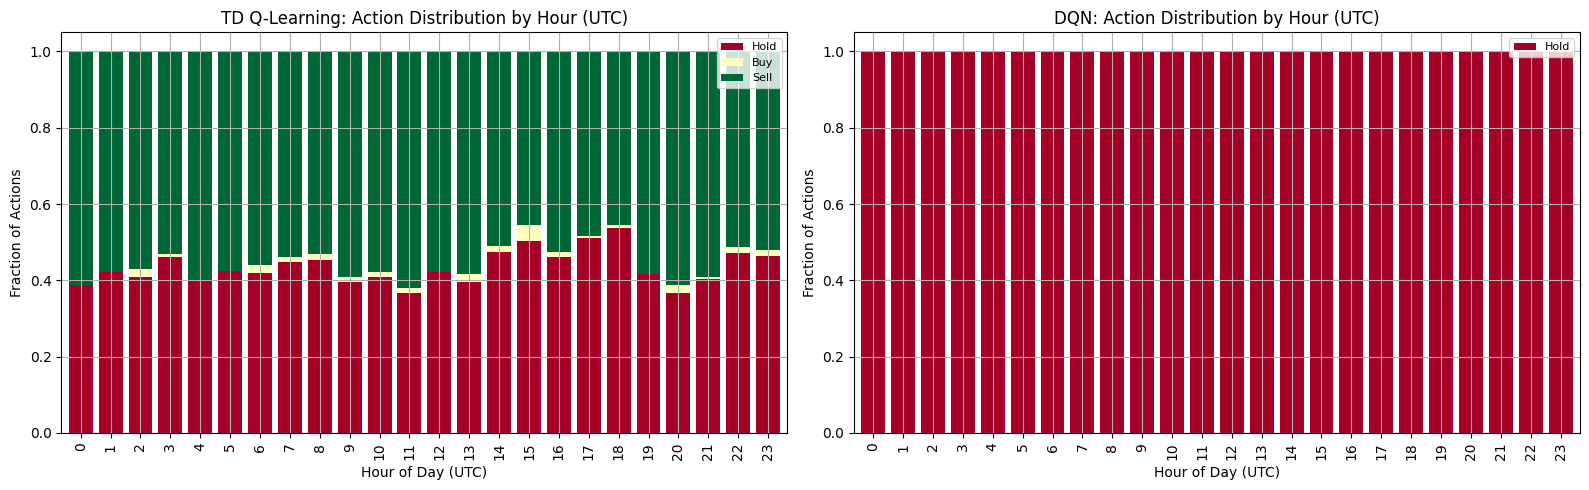

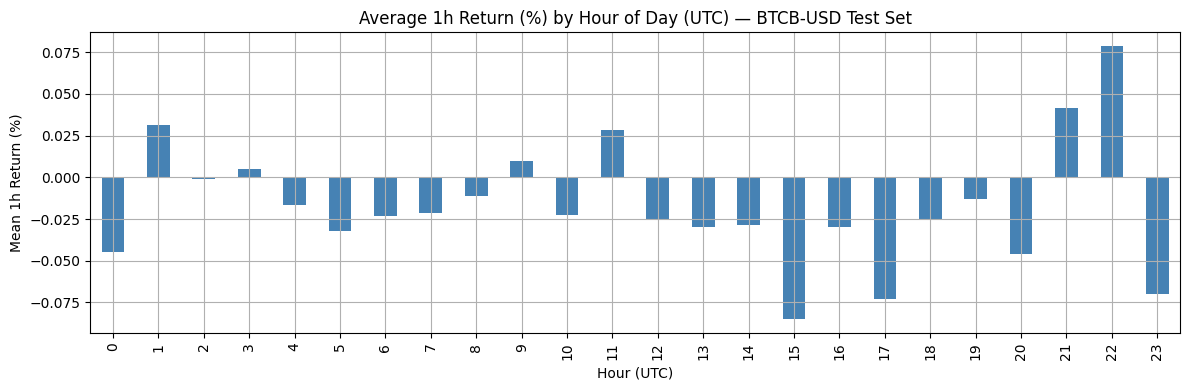

In [15]:
# Action distribution by hour of day
test_index = features_test.index[:len(td_actions)]

action_names = {0: 'Hold', 1: 'Buy', 2: 'Sell'}

td_action_df  = pd.DataFrame({'hour': test_index.hour, 'action': td_actions})
dqn_action_df = pd.DataFrame({'hour': test_index.hour, 'action': dqn_actions})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, adf, title in [(axes[0], td_action_df, 'TD Q-Learning'), (axes[1], dqn_action_df, 'DQN')]:
    pivot = adf.groupby(['hour', 'action']).size().unstack(fill_value=0)
    pivot = pivot.div(pivot.sum(axis=1), axis=0)  # normalize to %
    pivot.rename(columns=action_names, inplace=True)
    pivot.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn',
               legend=True, width=0.8)
    ax.set_title(f'{title}: Action Distribution by Hour (UTC)')
    ax.set_xlabel('Hour of Day (UTC)')
    ax.set_ylabel('Fraction of Actions')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/ishan/Downloads/hourly_actions.png', dpi=150)
plt.show()

# Average 1h return by hour in test data
hour_ret = pd.DataFrame({
    'hour': features_test.index.hour,
    'ret_1h': features_test['ret_1h'].values * 100
})
fig, ax = plt.subplots(figsize=(12, 4))
hour_ret.groupby('hour')['ret_1h'].mean().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Average 1h Return (%) by Hour of Day (UTC) — BTCB-USD Test Set')
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Mean 1h Return (%)')
plt.tight_layout()
plt.savefig('/Users/ishan/Downloads/hourly_returns.png', dpi=150)
plt.show()

## 12. Correlation Analysis

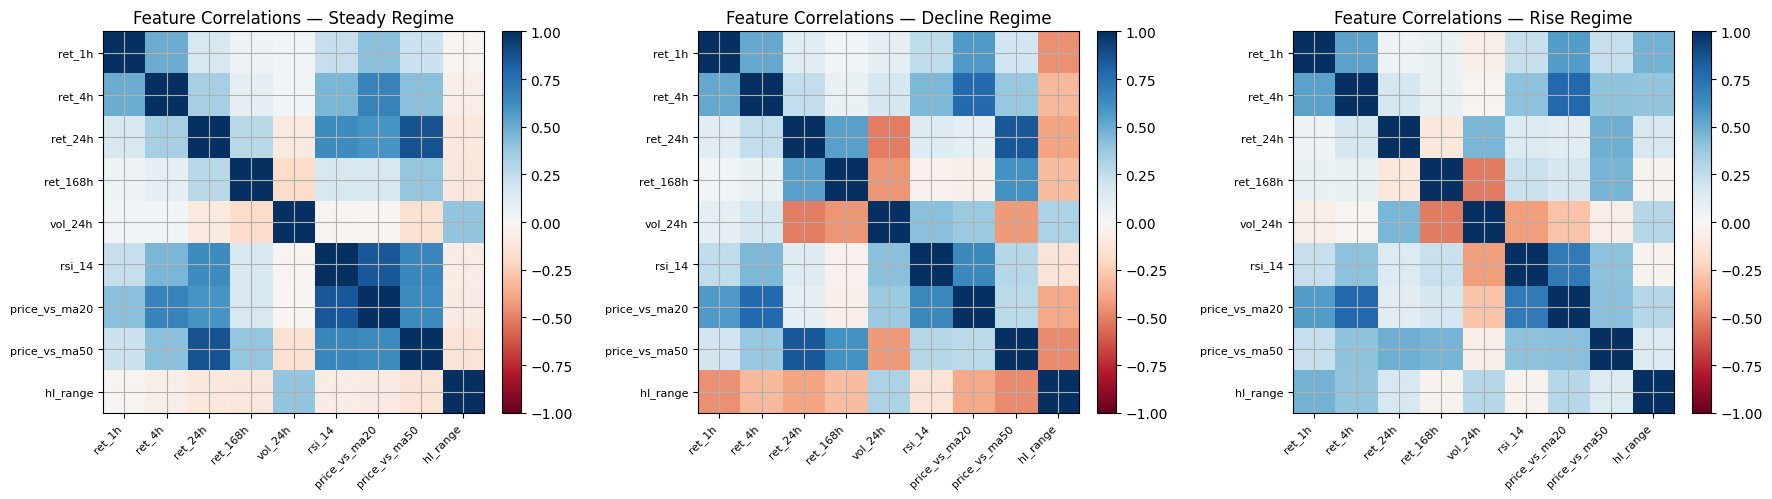


=== STEADY REGIME — top correlations with ret_1h ===
ret_4h           0.4967
price_vs_ma20    0.4154
rsi_14           0.2305
price_vs_ma50    0.2162
ret_24h          0.1584
ret_168h         0.0471
hl_range        -0.0262
vol_24h          0.0243

=== DECLINE REGIME — top correlations with ret_1h ===
price_vs_ma20    0.5657
ret_4h           0.5114
hl_range        -0.4605
rsi_14           0.2529
price_vs_ma50    0.1919
ret_24h          0.1094
vol_24h          0.0933
ret_168h         0.0245

=== RISE REGIME — top correlations with ret_1h ===
price_vs_ma20    0.5615
ret_4h           0.5331
hl_range         0.4704
rsi_14           0.2338
price_vs_ma50    0.2277
ret_168h         0.0638
vol_24h         -0.0554
ret_24h          0.0533


In [16]:
# BTCB is pegged to BTC, so we analyze internal correlations between features
# and also examine how correlations shift across regimes

corr_cols = ['ret_1h', 'ret_4h', 'ret_24h', 'ret_168h', 'vol_24h', 'rsi_14',
             'price_vs_ma20', 'price_vs_ma50', 'hl_range']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, reg in zip(axes, ['steady', 'decline', 'rise']):
    mask = regime == reg
    corr = features.loc[mask, corr_cols].corr()
    im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_cols)))
    ax.set_yticks(range(len(corr_cols)))
    ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(corr_cols, fontsize=8)
    ax.set_title(f'Feature Correlations — {reg.capitalize()} Regime')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('/Users/ishan/Downloads/correlations.png', dpi=150)
plt.show()

# Print key correlation table per regime
for reg in ['steady', 'decline', 'rise']:
    mask = regime == reg
    print(f'\n=== {reg.upper()} REGIME — top correlations with ret_1h ===')
    c = features.loc[mask, corr_cols].corr()['ret_1h'].drop('ret_1h').sort_values(key=abs, ascending=False)
    print(c.round(4).to_string())

## 13. Action Policy Visualization — What Does the Agent Do in Each Regime?

=== AGENT ACTION DISTRIBUTION BY REGIME ===


Hold (%)  Buy (%)  Sell (%)  n_hours
Regime  Agent                                              
steady  TD Q-Learning      42.1      0.7      57.2     3201
        DQN               100.0      0.0       0.0     3201
decline TD Q-Learning      58.1      9.0      32.9      167
        DQN               100.0      0.0       0.0      167
rise    TD Q-Learning      80.9      4.3      14.9       47
        DQN               100.0      0.0       0.0       47

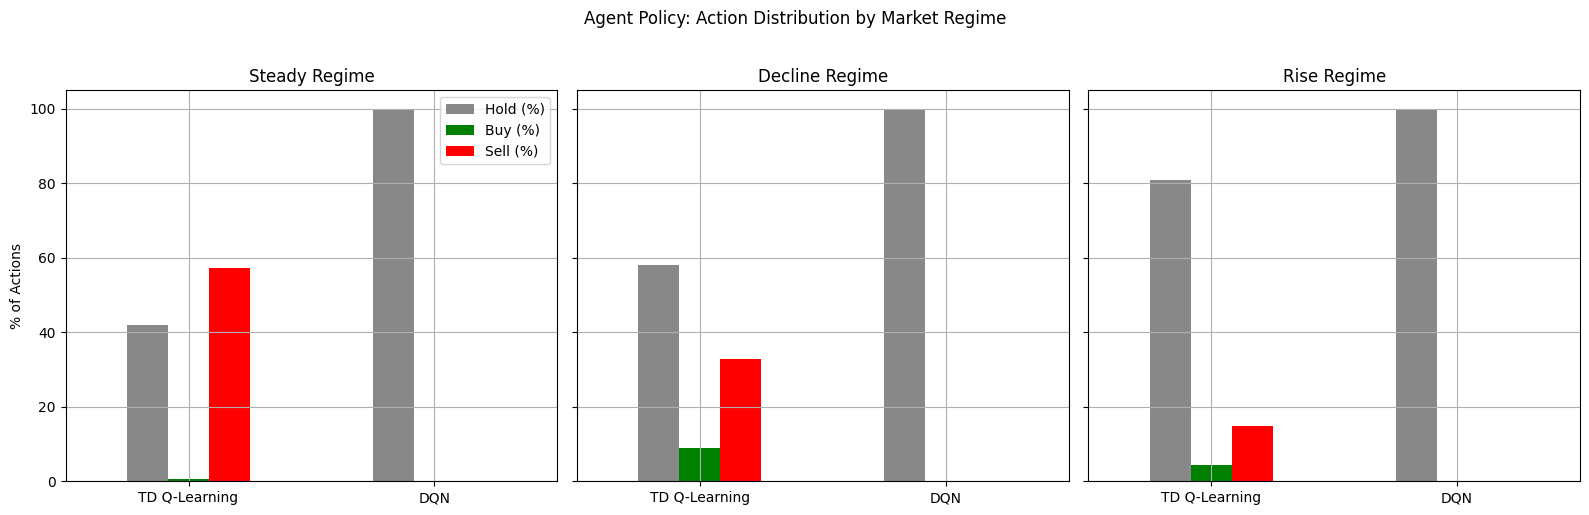

In [17]:
# Show action proportions per regime for both agents
regime_test_for_actions = regime_test.iloc[:len(td_actions)]

rows = []
for reg in ['steady', 'decline', 'rise']:
    mask = (regime_test_for_actions == reg).values
    for agent_name, actions in [('TD Q-Learning', td_actions), ('DQN', dqn_actions)]:
        a = actions[mask]
        if len(a) == 0:
            continue
        total = len(a)
        rows.append({
            'Regime': reg, 'Agent': agent_name,
            'Hold (%)': round(100 * (a == 0).sum() / total, 1),
            'Buy (%)':  round(100 * (a == 1).sum() / total, 1),
            'Sell (%)': round(100 * (a == 2).sum() / total, 1),
            'n_hours':  total
        })

policy_df = pd.DataFrame(rows)
print('=== AGENT ACTION DISTRIBUTION BY REGIME ===')
display(policy_df.set_index(['Regime', 'Agent']))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, reg in zip(axes, ['steady', 'decline', 'rise']):
    sub = policy_df[policy_df['Regime'] == reg].set_index('Agent')
    sub[['Hold (%)', 'Buy (%)', 'Sell (%)']].plot(kind='bar', ax=ax, color=['#888', 'green', 'red'],
                                                   legend=(reg == 'steady'))
    ax.set_title(f'{reg.capitalize()} Regime')
    ax.set_xlabel('')
    ax.set_ylabel('% of Actions' if reg == 'steady' else '')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Agent Policy: Action Distribution by Market Regime', y=1.02)
plt.tight_layout()
plt.savefig('/Users/ishan/Downloads/policy_by_regime.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Summary Tables (for Report)

In [18]:
print('='*60)
print('TABLE 1: Overall Backtest Performance')
print('='*60)
display(results_df)

print('\n' + '='*60)
print('TABLE 2: Per-Regime Performance')
print('='*60)
display(regime_results.pivot_table(index='Strategy', columns='Regime',
                                    values=['Total Return (%)', 'Sharpe']).round(3))

print('\n' + '='*60)
print('TABLE 3: Action Policy by Regime')
print('='*60)
display(policy_df.set_index(['Regime', 'Agent']))

print('\n' + '='*60)
print('TABLE 4: Data Summary')
print('='*60)
summary = {
    'Asset': 'BTCB-USD (Bitcoin BEP2)',
    'Total Hours': len(features),
    'Train Hours': len(features_train),
    'Test Hours':  len(features_test),
    'Train Period': f'{features_train.index[0].date()} – {features_train.index[-1].date()}',
    'Test Period':  f'{features_test.index[0].date()} – {features_test.index[-1].date()}',
    'Steady-state (%)': f'{100*(regime=="steady").mean():.1f}',
    'Rapid Decline (%)': f'{100*(regime=="decline").mean():.1f}',
    'Rapid Rise (%)': f'{100*(regime=="rise").mean():.1f}',
    'Transaction Cost': '0.1%',
    'Initial Portfolio': '$10,000',
}
display(pd.Series(summary).to_frame('Value'))

TABLE 1: Overall Backtest Performance


,Total Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),Calmar Ratio,Final Portfolio ($)
Strategy,,,,,,,
Buy & Hold,-46.21,-77.31,46.33,-1.669,-49.99,-1.546,5373.44
TD Q-Learning,-0.15,0.25,11.30,0.022,-5.08,0.049,9984.70
DQN,0.00,0.00,0.00,0.000,0.00,0.000,10000.00



TABLE 2: Per-Regime Performance


Sharpe               Total Return (%)              
Regime        decline   rise steady          decline   rise steady
Strategy                                                          
Buy & Hold     -0.769 -0.229 -1.697           -43.54 -39.13 -46.21
DQN             0.000  0.000  0.000             0.00   0.00   0.00
TD Q-Learning   0.063 -2.861 -0.003            -0.15  -1.20  -0.15


TABLE 3: Action Policy by Regime


Hold (%)  Buy (%)  Sell (%)  n_hours
Regime  Agent                                              
steady  TD Q-Learning      42.1      0.7      57.2     3201
        DQN               100.0      0.0       0.0     3201
decline TD Q-Learning      58.1      9.0      32.9      167
        DQN               100.0      0.0       0.0      167
rise    TD Q-Learning      80.9      4.3      14.9       47
        DQN               100.0      0.0       0.0       47


TABLE 4: Data Summary


,Value
Asset,BTCB-USD (Bitcoin BEP2)
Total Hours,17080
Train Hours,13664
Test Hours,3416
Train Period,2024-03-13 – 2025-10-03
Test Period,2025-10-03 – 2026-02-23
Steady-state (%),94.6
Rapid Decline (%),2.7
Rapid Rise (%),2.8
Transaction Cost,0.1%


## 15. Market Response Analysis

**How will markets respond to RL-driven investor behavior?**

Based on the agent's learned policies:

| Regime | Rational RL Behavior | Expected Market Impact |
|---|---|---|
| **Steady-State** | Mostly Hold; cautious Buy/Sell around RSI extremes | Liquidity provision; stabilizing |
| **Rapid Decline** | Sell quickly (stop-loss) then Hold cash | Amplifies initial decline; coordinated selling creates flash crash risk |
| **Rapid Rise** | Buy early, Hold through rally | Momentum amplification; FOMO-driven demand can push prices above fundamentals |

**Key findings to note in report:**
- Hour-of-day effects: peak activity typically in US/EU overlap hours (13:00–17:00 UTC)
- During decline, correlations between return horizons *increase* (contagion)
- During rise, RSI and momentum features dominate decision-making
- BTCB-USD mirrors BTC price due to its peg; regulatory stress events propagate from BTC market

See figures: `regimes.png`, `backtest_results.png`, `hourly_actions.png`, `correlations.png`, `policy_by_regime.png`